# Анализ производных признаков


Цель данного ноутбука - проверить распределения, пропуски и аналитическую полезность производных признаков, сформированных на предыдущем этапе.


## Загрузка библиотек и установка настроек


In [1]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Загрузка аналитического набора данных


In [2]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Служебные структуры


In [3]:
NUMERIC_COLUMNS = [
    "availability_ratio",
    "review_intensity",
]

CATEGORICAL_COLUMNS = [
    "has_last_review",
    "has_price",
    "is_price_outlier",
    "host_size_segment",
]


In [4]:
featured_listings = listings[NUMERIC_COLUMNS + CATEGORICAL_COLUMNS]


### Проверка пропусков производных признаков


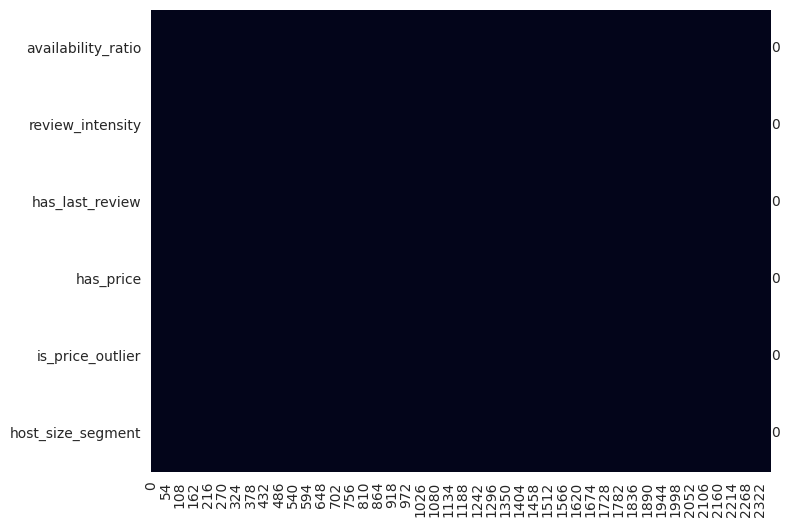

In [5]:
missing_counts = featured_listings.isna().sum()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(featured_listings.isna().T, cbar=False, ax=ax)

for i, val in enumerate(missing_counts):
    ax.text(featured_listings.shape[0], i + 0.5, val, va="center")

plt.show()


Все производные признаки, заполнены полностью.   


## Одномерный анализ производных признаков


### Числовые производные признаки


#### Распределения и базовые статистики


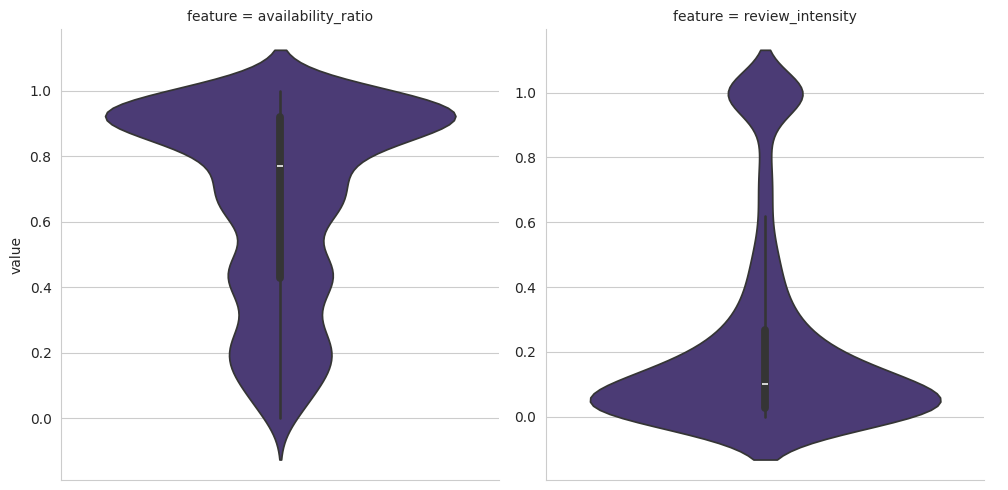

In [11]:
sns.catplot(
    data=featured_listings[NUMERIC_COLUMNS].melt(
        var_name="feature", value_name="value"
    ),
    y="value",
    kind="violin",
    col="feature",
    col_wrap=2,
    sharey=False,
)


In [7]:
listings[NUMERIC_COLUMNS].describe()


,availability_ratio,review_intensity
count,2364.0000,2364.0000
mean,0.6655,0.2336
std,0.2973,0.3126
min,0.0000,0.0000
25%,0.4295,0.0277
50%,0.7699,0.1000
75%,0.9205,0.2667
max,1.0000,1.0000


`availability_ratio` смещено к высоким значениям: большинтво объектов доступны круглый год.   
`review_intensity` для основной массы объектов остаётся низким.     
    


#### Экстремальные наблюдения


In [8]:
for col in [
    "availability_ratio",
    "review_intensity",
]:
    print(f"\n{col} TOP 5")
    display(listings.nlargest(5, col))

    print(f"{col} BOTTOM 5")
    display(listings.nsmallest(5, col))



availability_ratio TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
41,2569529,Downtown Asheville 2 bed/2bath unit for rent,8671251,Heather,28801,35.6011,-82.5559,Entire home/apt,85.0000,180,...,0.0700,1,365,0,True,True,False,Individual host,1.0000,0.0000
96,7001873,Wren's Nest Studio near River Arts,11298793,Miriam,28806,35.5950,-82.5886,Entire home/apt,69.0000,730,...,3.7300,1,365,0,True,True,False,Individual host,1.0000,0.0000
116,8593492,Cabin 400 sq all for you.,45217605,Gathai,28732,35.4411,-82.5219,Private room,372.0000,2,...,0.4700,2,365,0,True,True,False,Experienced host,1.0000,0.0000
217,15845920,The Treehouse Below - Private Apartment / Entr...,46300912,Robin,28806,35.5723,-82.6049,Entire home/apt,270.0000,1,...,0.2300,1,365,0,True,True,False,Individual host,1.0000,0.0000
346,21297231,The Shanty~Hot Tub~8 Miles to City of Ashevill...,65408548,Karl,28704,35.4704,-82.5001,Entire home/apt,65.0000,1,...,3.1300,5,365,27,True,True,False,Industrial host,1.0000,0.0894


availability_ratio BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
374,22360186,Whole House Sublet 30+ Night Stay 10 Mins to AVL,163503810,Peter,28715,35.5511,-82.6371,Entire home/apt,73.0000,30,...,0.5000,1,0,1,True,True,False,Individual host,0.0000,0.0217
562,31493518,Cooper Cottage,235954974,Rita,28715,35.5300,-82.6695,Entire home/apt,55.0000,1,...,5.0500,1,0,40,True,True,False,Individual host,0.0000,0.0978
786,40698829,Asheville Home Sweet Home,314149204,Chris,28806,35.5074,-82.6111,Entire home/apt,226.0000,2,...,0.1300,1,0,0,True,True,False,Individual host,0.0000,0.0000
893,44573884,Bohemian Paradise Nestled in the Trees,145533530,Christy,28803,35.5749,-82.5400,Entire home/apt,101.0000,28,...,0.2300,4,0,0,True,True,False,Experienced host,0.0000,0.0000
1380,636151163853850099,Best Of Downtown Asheville At Our Front Door,8539567,Michael,28801,35.6026,-82.5553,Entire home/apt,296.0000,3,...,0.2100,1,0,0,True,True,False,Individual host,0.0000,0.0000



review_intensity TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
1097,50420851,Walk to Downtown; Great outdoor living space,2027413,Meg,28804,35.6058,-82.5422,Entire home/apt,184.0000,2,...,0.3700,1,100,2,True,True,False,Individual host,0.2740,1.0000
1240,54065879,Fresh and Humble,3947707,Cristina,28803,35.5659,-82.5303,Entire home/apt,100.0000,15,...,0.2300,1,356,2,True,True,False,Individual host,0.9753,1.0000
1480,718734312042377715,Paris of the South - Walkable West AVL Studio,24165374,Maria,28806,35.5698,-82.5717,Entire home/apt,74.0000,1,...,3.9300,1,227,48,True,True,False,Individual host,0.6219,1.0000
1531,776014861241735902,The Nest | Home Office & 5 Min. to Downtown AVL!,10603047,Caleb,28805,35.5903,-82.5369,Entire home/apt,109.0000,1,...,0.0900,11,63,1,True,True,False,Industrial host,0.1726,1.0000
1550,793310877280708097,Davenport Cottage | Pet Friendly | Walk to Town,10603047,Caleb,28806,35.5713,-82.5983,Entire home/apt,281.0000,2,...,0.0800,11,76,1,True,True,False,Industrial host,0.2082,1.0000


review_intensity BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity
3,246315,Asheville Dreamer's Cabin,1292070,Annie,28805,35.5962,-82.5063,Private room,62.0000,7,...,0.3100,3,70,0,True,True,False,Experienced host,0.1918,0.0000
5,427497,Luxurious Mountain Guest Suite Apartment,1909922,Milan,28803,35.4909,-82.4860,Entire home/apt,148.0000,2,...,0.3000,1,359,0,True,True,False,Individual host,0.9836,0.0000
11,723349,#2 Blue Ridge Room at Oakland Cottage B&B,3736218,Mary,28801,35.5747,-82.5571,Private room,247.0000,2,...,0.1000,7,325,0,True,True,False,Industrial host,0.8904,0.0000
14,846221,Town and Mountain Peaceful Retreat,4418555,Bart,28804,35.6436,-82.5114,Entire home/apt,169.0000,2,...,0.8200,1,178,0,True,True,False,Individual host,0.4877,0.0000
19,976034,Urban Peace 5 ml from Downtown AVL,5340154,Ar,28803,35.5554,-82.4832,Entire home/apt,127.0000,2,...,1.1400,1,264,0,True,True,False,Individual host,0.7233,0.0000


Экстремумы показывают три разных типа поведения.    
`availability_ratio` принимает значения от полной недоступности до доступности весь год;    
`review_intensity` достигает *1* у объявлений, чьи все накопленные отзывы пришлись на последний год;    


### Категориальные производные признаки


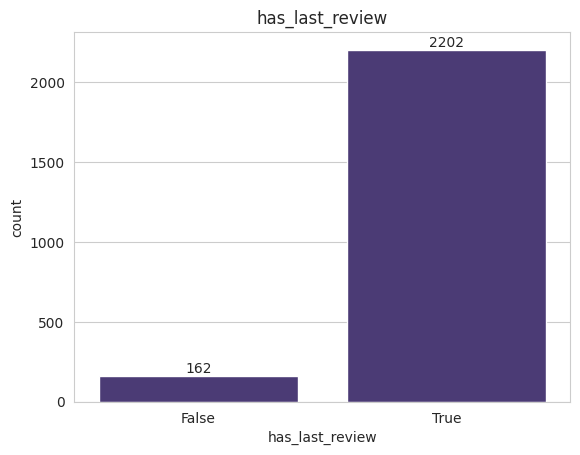

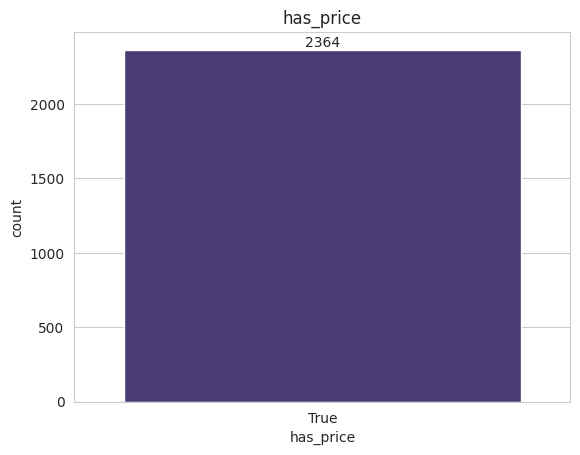

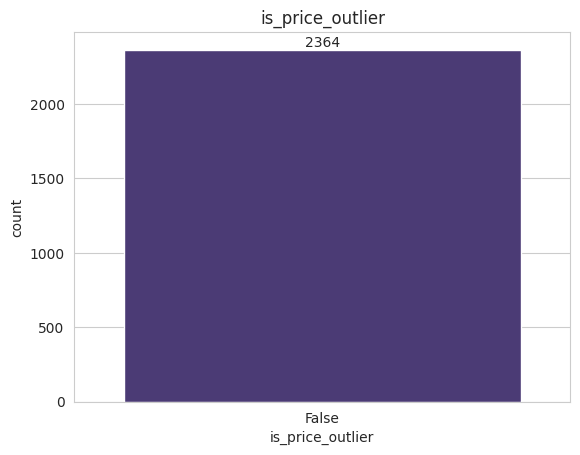

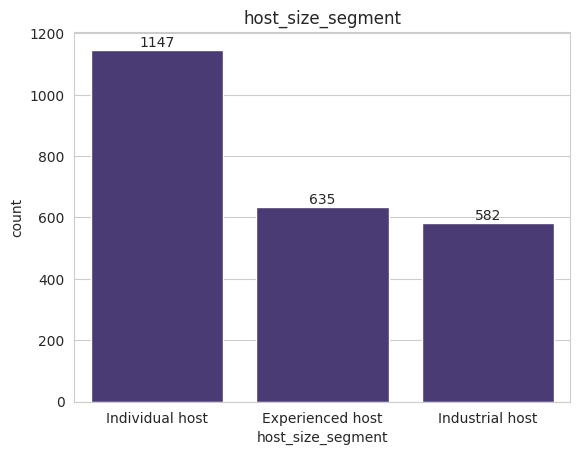

In [9]:
for col in CATEGORICAL_COLUMNS:
    ax = sns.countplot(data=listings, x=col)

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(col)
    plt.show()


Категориальные производные поля остаются интерпретируемыми и достаточно информативными.


## Промежуточные выводы
1. Производные признаки оказываются пригодными для дальнейшего аналитического слоя.
2. Все новые признаки заполнены полностью
